# CIFAR-10 with a Cauchy-Activated CNN

This notebook builds a full CNN in-place (no MLP from src) to classify CIFAR-10.
The model supports `activation_mode = "cauchy"` or `"relu"` for quick comparisons.

In [1]:
# ===== 导入必要的库 =====
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# ===== 设置随机种子确保可复现性 =====
# 固定各个随机数生成器的种子，确保结果可复现
seed = 42
random.seed(seed)  # Python随机数
np.random.seed(seed)  # Numpy随机数
torch.manual_seed(seed)  # PyTorch CPU随机数
torch.cuda.manual_seed_all(seed)  # PyTorch GPU随机数

# ===== 设置计算设备 =====
# 如果GPU可用则使用GPU，否则回退到CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
@dataclass
class Config:
    """
    全局配置类：包含所有训练相关的超参数。
    
    属性解释：
        batch_size (int)：每个batch包含的样本数，128
        epochs (int)：总的训练轮数，20
        lr (float)：初始学习率（AdamW优化器），1e-3
        weight_decay (float)：L2正则化系数，防止过拟合，1e-4
        num_workers (int)：DataLoader中的加载进程数，2
        base_channels (int)：CNN的基础通道数，后续层通道数为此的倍数，64
    """
    batch_size: int = 128
    epochs: int = 20
    lr: float = 1e-3
    weight_decay: float = 1e-4
    num_workers: int = 2
    base_channels: int = 64

cfg = Config()

# ===== Ablation实验配置网格 =====
# 对所有残差模式和激活模式的组合进行4次实验
experiment_grid = [
    ("standard", "relu"),  # 实验1：标准残差 + ReLU激活
    ("standard", "cauchy"),  # 实验2：标准残差 + Cauchy激活
    ("cauchy", "relu"),  # 实验3：Cauchy残差 + ReLU激活
    ("cauchy", "cauchy"),  # 实验4：Cauchy残差 + Cauchy激活（完整版本）
]

cfg

Config(batch_size=128, epochs=20, lr=0.001, weight_decay=0.0001, num_workers=2, base_channels=64)

In [3]:
import os

# 配置网络代理（用于从互联网下载数据集）
os.environ["HTTP_PROXY"] = "http://127.0.0.1:7890"
os.environ["HTTPS_PROXY"] = "http://127.0.0.1:7890"

# ===== 图像归一化参数 =====
# CIFAR-100图像数据的均值和标准差（RGB三个通道）
# 这些值通过对整个训练集计算得出
mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

# ===== 训练集数据增强 =====
# 包含几何变换和归一化，增加训练数据多样性
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),  # 随机裁剪，边界补0
    transforms.RandomHorizontalFlip(),  # 50%概率水平翻转
    transforms.ToTensor(),  # 转为张量并归一化到[0, 1]
    transforms.Normalize(mean, std),  # 标准化到均值0、方差1
])

# ===== 测试集数据预处理 =====
# 不做增强，只做标准化
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# ===== 加载CIFAR-100数据集 =====
# CIFAR-100：50000张训练图像 + 10000张测试图像，100个类别
train_ds = datasets.CIFAR100(root="./data", train=True, download=True, transform=train_transform)
test_ds = datasets.CIFAR100(root="./data", train=False, download=True, transform=test_transform)

# ===== 创建DataLoader =====
# DataLoader用于批量加载和预处理数据
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,  # 128
    shuffle=True,  # 训练集打乱
    num_workers=cfg.num_workers,  # 多进程加载
    pin_memory=(device.type == "cuda"),  # GPU训练时锁定内存加速传输
)
test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,  # 测试集不打乱，便于记录
    num_workers=cfg.num_workers,
    pin_memory=(device.type == "cuda"),
)

# ===== 获取类别信息 =====
classes = train_ds.classes  # 100个类别名称列表
print(f"Train samples: {len(train_ds)}, Test samples: {len(test_ds)}")
print(classes)

/data1/linjiangtao2024/cauchy_activation/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train samples: 50000, Test samples: 10000
['apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine', 'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip', 'tu

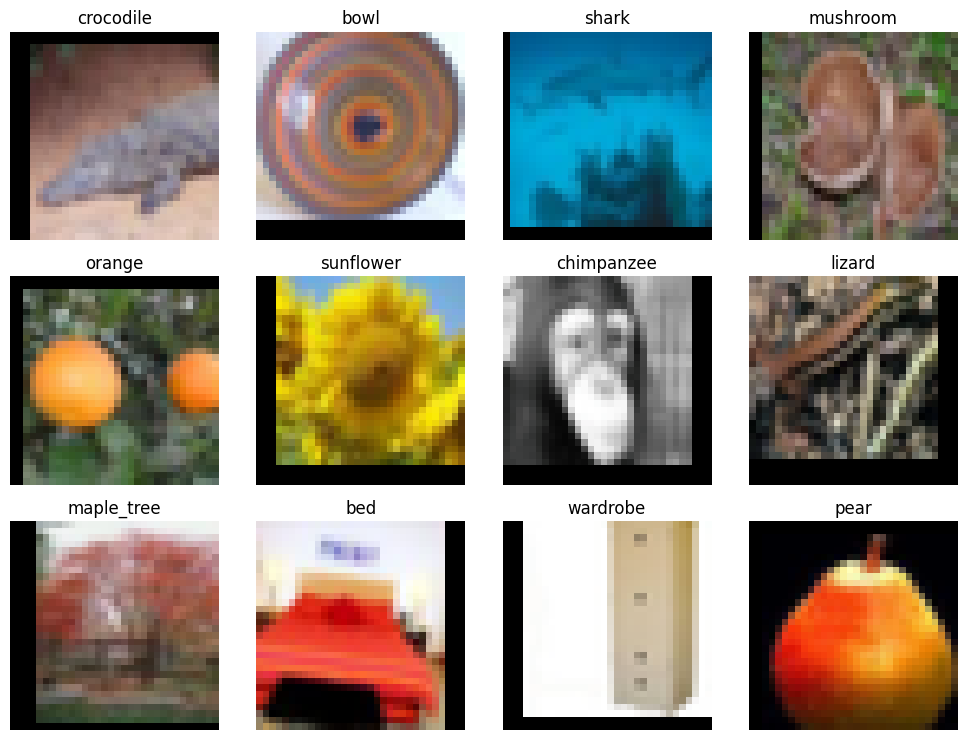

In [4]:
def show_batch(dl, class_names, n=12):
    """
    可视化数据加载器中的一个batch的图像及其标签。
    
    流程：
        1. 从DataLoader中获取一个batch
        2. 反归一化图像（从标准化后的值恢复到[0,1]范围）
        3. 在网格中绘制图像和对应的类别标签
    
    参数：
        dl (DataLoader)：数据加载器
        class_names (list)：类别名称列表
        n (int)：显示的图像数量，默认12
    """
    # 获取第一个batch
    xb, yb = next(iter(dl))
    xb = xb[:n]
    yb = yb[:n]

    # ===== 反归一化图像 =====
    # 将标准化后的图像恢复到[0,1]范围
    # 标准化公式：x_norm = (x - mean) / std
    # 反标准化公式：x = x_norm * std + mean
    xb = xb * torch.tensor(std).view(1, 3, 1, 1) + torch.tensor(mean).view(1, 3, 1, 1)
    xb = xb.clamp(0, 1)  # 裁剪到[0,1]范围以处理数值误差

    # ===== 创建图像网格 =====
    cols = 4  # 每行显示4张图像
    rows = int(np.ceil(n / cols))  # 计算需要的行数
    plt.figure(figsize=(10, 2.5 * rows))
    
    for i in range(n):
        plt.subplot(rows, cols, i + 1)
        # 将张量从(C, H, W)转置为(H, W, C)以用于imshow
        plt.imshow(np.transpose(xb[i].numpy(), (1, 2, 0)))
        # 显示对应的类别名称作为标题
        plt.title(class_names[int(yb[i])])
        plt.axis("off")
    plt.tight_layout()

# 展示12张样本图像
show_batch(train_loader, classes, n=12)

In [5]:
class CauchyActivation(nn.Module):
    """
    自定义Cauchy激活函数。
    
    公式：output = lambda1 * x / (x^2 + d^2) + lambda2 / (x^2 + d^2)
    这是一个可学习的激活函数，通过参数lambda1, lambda2和d来自适应地调整激活行为。
    
    参数：
        lambda1 (float)：x的系数，控制激活函数对输入的响应程度。默认1.0
        lambda2 (float)：常数项系数，添加一个偏置项。默认0.0
        d (float)：Cauchy分布的形状参数，控制激活函数的宽度。默认1.0
    
    属性：
        lambda1 (Parameter)：可学习的lambda1参数
        lambda2 (Parameter)：可学习的lambda2参数
        raw_d (Parameter)：raw_d通过softplus变换得到d，确保d > 0
    """
    def __init__(self, lambda1=1.0, lambda2=0.0, d=1.0):
        super().__init__()
        self.lambda1 = nn.Parameter(torch.tensor(float(lambda1)))
        self.lambda2 = nn.Parameter(torch.tensor(float(lambda2)))
        # 使用raw_d并通过softplus变换，确保d始终为正
        self.raw_d = nn.Parameter(torch.tensor(float(d)))

    def forward(self, x):
        """
        前向传播。
        
        参数：
            x (Tensor)：输入张量，任意形状
            
        返回：
            Tensor：应用Cauchy激活后的输出，形状与输入相同
        """
        # softplus(x) = log(1 + exp(x))，确保d > 0，+ 1e-6防止除数为0
        d = F.softplus(self.raw_d) + 1e-6
        # x^2 + d^2作为分母
        denom = x.pow(2) + d.pow(2)
        # 返回Cauchy激活函数的结果
        return self.lambda1 * x / denom + self.lambda2 / denom


def get_activation(mode):
    """
    根据指定模式返回相应的激活函数。
    
    参数：
        mode (str)：激活函数模式，可选值为 'cauchy' 或 'relu'
        
    返回：
        nn.Module：对应的激活函数实例
        
    异常：
        ValueError：如果mode不是'cauchy'或'relu'
    """
    if mode == "cauchy":
        return CauchyActivation()
    if mode == "relu":
        return nn.ReLU(inplace=True)
    raise ValueError("activation_mode must be 'cauchy' or 'relu'")


class ConvTransformBlock(nn.Module):
    """
    卷积变换块：包含两个卷积层、两个批归一化层和可选Dropout。
    
    结构：
        Conv2d(3x3) -> BatchNorm -> Activation -> Conv2d(3x3) -> BatchNorm -> Dropout
    
    这个块用于学习特征变换，是ResidualStage中的基本组件。
    
    参数：
        channels (int)：输入和输出通道数
        activation_mode (str)：激活函数模式，'cauchy'或'relu'。默认'cauchy'
        dropout (float)：Dropout概率。默认0.0（不使用Dropout）
    
    属性：
        conv1, conv2 (Conv2d)：两个3x3卷积层
        bn1, bn2 (BatchNorm2d)：两个批归一化层
        act1 (nn.Module)：第一个激活函数（在卷积1之后）
        dropout (nn.Module)：Dropout层
    """
    def __init__(self, channels, activation_mode="cauchy", dropout=0.0):
        super().__init__()
        # 第一个卷积分支：Conv -> BN -> Activation
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.act1 = get_activation(activation_mode)

        # 第二个卷积分支：Conv -> BN
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        # 可选的Dropout层
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        """
        前向传播。
        
        参数：
            x (Tensor)：输入张量，形状为(B, C, H, W)
            
        返回：
            Tensor：输出张量，形状与输入相同
        """
        # 第一分支：卷积 -> 批归一化 -> 激活
        h = self.conv1(x)
        h = self.bn1(h)
        h = self.act1(h)

        # 第二分支：卷积 -> 批归一化 -> Dropout
        h = self.conv2(h)
        h = self.bn2(h)
        h = self.dropout(h)
        return h


class ResidualStage(nn.Module):
    """
    残差阶段模块：包含多个ConvTransformBlock，支持两种残差连接模式。
    
    两种残差模式：
        1. "standard"：标准残差连接 h = h + transformed
        2. "cauchy"：Cauchy加权混合模式，mix = Cauchy加权的历史激活 + 当前变换
                    这种模式会保留历史层的特征信息，通过Cauchy距离加权
    
    关键特性：
        - 维护激活历史：记录每层的输入
        - Cauchy距离加权：使用可学习的lambda和d参数对历史做加权平均
        - 距离度量：距离 = 从当前层到历史层的索引差
    
    参数：
        channels (int)：通道数
        num_blocks (int)：该阶段包含的ConvTransformBlock数量
        activation_mode (str)：激活函数模式。默认'cauchy'
        residual_mode (str)：残差连接模式，'standard'或'cauchy'。默认'standard'
        dropout (float)：Dropout概率。默认0.0
        
    属性：
        residual_mode (str)：残差模式
        blocks (ModuleList)：包含的卷积块列表
        post_act (nn.Module)：阶段后的激活函数
        mix_raw_lambda (Parameter)：原始lambda参数（通过softplus激活），形状(num_blocks+1,)
        mix_raw_d (Parameter)：原始d参数（通过softplus激活），形状(num_blocks+1,)
    """
    def __init__(self, channels, num_blocks, activation_mode="cauchy", residual_mode="standard", dropout=0.0):
        super().__init__()
        if residual_mode not in {"standard", "cauchy"}:
            raise ValueError("residual_mode must be 'standard' or 'cauchy'")

        self.residual_mode = residual_mode
        # 创建num_blocks个卷积变换块
        self.blocks = nn.ModuleList(
            [ConvTransformBlock(channels, activation_mode=activation_mode, dropout=dropout) for _ in range(num_blocks)]
        )
        # 每个块后的激活函数
        self.post_act = get_activation(activation_mode)

        # Cauchy加权参数：num_blocks + 1是因为包括输入和所有块的输出
        self.mix_raw_lambda = nn.Parameter(torch.zeros(num_blocks + 1))
        self.mix_raw_d = nn.Parameter(torch.ones(num_blocks + 1))

    def _cauchy_mix(self, history, target_layer):
        """
        Cauchy距离加权混合历史激活。
        
        实现原理：
            1. 为每个历史层计算距离：distance = target_layer - history_index
            2. 计算Cauchy权重：weight[i] = lambda / (distance[i]^2 + d^2)
            3. 归一化权重使其求和为1
            4. 对历史激活进行加权平均
        
        参数：
            history (list)：历史激活列表，从旧到新排列
            target_layer (int)：当前目标层的索引
            
        返回：
            Tensor：加权混合后的激活，形状与history中单个元素相同
        """
        # 从参数中获取可学习的lambda和d值
        lam = F.softplus(self.mix_raw_lambda[target_layer]) + 1e-6
        d = F.softplus(self.mix_raw_d[target_layer]) + 1e-6
        count = len(history)

        # 计算历史中每个元素到当前层的距离
        # 距离从target_layer开始逐渐增大，最近的层距离最小
        distances = torch.arange(
            target_layer, target_layer - count, -1, device=history[0].device
        ).float()
        # Cauchy距离加权：距离越小权重越大
        weights = lam / (distances.pow(2) + d.pow(2))
        # 归一化权重
        weights = weights / (weights.sum() + 1e-8)

        # 将历史激活堆叠为5D张量：(序列长度, B, C, H, W)
        stacked = torch.stack(history, dim=0)
        # 按权重加权求和：(1, B, C, H, W) -> (B, C, H, W)
        return (weights[:, None, None, None, None] * stacked).sum(dim=0)

    def forward(self, x):
        """
        前向传播。
        
        参数：
            x (Tensor)：输入张量，形状为(B, C, H, W)
            
        返回：
            Tensor：经过所有块和残差连接后的输出
        """
        h = x
        # 初始化历史激活列表，从输入开始
        history = [h]

        for layer_idx, block in enumerate(self.blocks, start=1):
            # 获取变换后的特征
            transformed = block(h)
            
            if self.residual_mode == "standard":
                # 标准残差连接：新 = 旧 + 变换
                h = h + transformed
            else:
                # Cauchy模式：新 = 变换 + Cauchy加权历史混合
                h = transformed + self._cauchy_mix(history, layer_idx)
            
            # 应用后激活
            h = self.post_act(h)
            # 记录当前激活到历史中，用于后续层的Cauchy混合
            history.append(h)

        return h


class CauchyCNN(nn.Module):
    """
    Cauchy激活的CNN模型，用于图像分类（如CIFAR-100）。
    
    架构设计：
        Stem(卷积+BN+激活) 
        -> Stage1(2个Block) -> MaxPool
        -> Down1(通道扩展卷积) -> Stage2(2个Block) -> MaxPool
        -> Down2(通道扩展卷积) -> Stage3(2个Block)
        -> Head(全局平均池化 -> 线性分类层)
    
    通道维度变化：
        输入 (B, 3, H, W)
        -> Stem (B, base_channels, H, W)
        -> Stage1 (B, base_channels, H/2, W/2)  # 经过MaxPool
        -> Down1+Stage2 (B, 2*base_channels, H/4, W/4)  # 通道翻倍，再池化
        -> Down2+Stage3 (B, 4*base_channels, H/8, W/8)  # 通道再翻倍
        -> Head -> (B, num_classes)
    
    参数：
        num_classes (int)：分类类别数。默认10
        base_channels (int)：基础通道数，后续阶段通道数为此的倍数。默认64
        activation_mode (str)：激活函数模式，'cauchy'或'relu'。默认'cauchy'
        residual_mode (str)：残差连接模式，'standard'或'cauchy'。默认'standard'
    
    属性：
        stem (Sequential)：主干网络入口
        stage1, stage2, stage3 (Sequential)：三个残差阶段
        down1, down2 (Sequential)：通道提升的卷积
        head (Sequential)：分类头
    """
    def __init__(self, num_classes=10, base_channels=64, activation_mode="cauchy", residual_mode="standard"):
        super().__init__()
        
        # ===== Stem：初始卷积层 =====
        # 将3通道RGB图像转换为base_channels特征图
        self.stem = nn.Sequential(
            nn.Conv2d(3, base_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            get_activation(activation_mode),
        )

        # ===== Stage 1：第一个残差阶段 =====
        # 2个residual块 + MaxPool（通道数不变，空间分辨率减半）
        self.stage1 = nn.Sequential(
            ResidualStage(
                base_channels,
                num_blocks=6,
                activation_mode=activation_mode,
                residual_mode=residual_mode,
                dropout=0.05,
            ),
            nn.MaxPool2d(2),  # H, W -> H/2, W/2
        )

        # ===== Down1：通道扩展层 =====
        # 将通道数从base_channels扩展到2*base_channels
        c2 = base_channels * 2
        self.down1 = nn.Sequential(
            nn.Conv2d(base_channels, c2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(c2),
            get_activation(activation_mode),
        )
        
        # ===== Stage 2：第二个残差阶段 =====
        # 2个residual块 + MaxPool（通道数 = 2*base_channels，空间再减半）
        self.stage2 = nn.Sequential(
            ResidualStage(
                c2,
                num_blocks=4,
                activation_mode=activation_mode,
                residual_mode=residual_mode,
                dropout=0.1,
            ),
            nn.MaxPool2d(2),  # H, W -> H/4, W/4
        )

        # ===== Down2：通道再次扩展层 =====
        # 将通道数从2*base_channels扩展到4*base_channels
        c3 = c2 * 2
        self.down2 = nn.Sequential(
            nn.Conv2d(c2, c3, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(c3),
            get_activation(activation_mode),
        )
        
        # ===== Stage 3：第三个残差阶段 =====
        # 2个residual块（通道数 = 4*base_channels，无池化）
        self.stage3 = ResidualStage(
            c3,
            num_blocks=4,
            activation_mode=activation_mode,
            residual_mode=residual_mode,
            dropout=0.1,
        )

        # ===== Head：分类头 =====
        # 全局平均池化 -> 展平 -> 线性分类
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # 任意分辨率 -> (1, 1)
            nn.Flatten(),  # (B, c3, 1, 1) -> (B, c3)
            nn.Linear(c3, num_classes),  # (B, c3) -> (B, num_classes)
        )

    def forward(self, x):
        """
        前向传播。
        
        参数：
            x (Tensor)：输入图像张量，形状为(B, 3, H, W)
            
        返回：
            Tensor：分类logits，形状为(B, num_classes)
        """
        x = self.stem(x)
        x = self.stage1(x)
        x = self.down1(x)
        x = self.stage2(x)
        x = self.down2(x)
        x = self.stage3(x)
        x = self.head(x)
        return x


preview_model = CauchyCNN(
    num_classes=len(classes),
    base_channels=cfg.base_channels,
    activation_mode="cauchy",
    residual_mode="cauchy",
).to(device)
num_params = sum(p.numel() for p in preview_model.parameters() if p.requires_grad)
print(preview_model.__class__.__name__)
print(f"Trainable params: {num_params:,}")

CauchyCNN
Trainable params: 6,745,346


In [6]:
# ===== 诊断：检查Cauchy激活的问题 =====
print("\n" + "="*80)
print("DIAGNOSIS: Cauchy Activation Issues")
print("="*80)

# 测试Cauchy激活的数值特性
cauchy_act = CauchyActivation(lambda1=1.0, lambda2=0.0, d=1.0)
test_inputs = torch.tensor([-5.0, -1.0, 0.0, 1.0, 5.0, 10.0])
cauchy_outputs = cauchy_act(test_inputs.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1))
cauchy_outputs = cauchy_outputs.squeeze()

print("\n问题1：Cauchy激活的值域")
print(f"输入范围: {test_inputs.min():.2f} ~ {test_inputs.max():.2f}")
print(f"输出范围: {cauchy_outputs.min():.6f} ~ {cauchy_outputs.max():.6f}")
print(f"输出均值: {cauchy_outputs.mean():.6f}")
print(f"问题: 大多数值都很小，接近0，梯度易消失！")

# 与ReLU对比
relu_act = nn.ReLU()
relu_outputs = relu_act(test_inputs)
print(f"\nReLU输出范围: {relu_outputs.min():.2f} ~ {relu_outputs.max():.2f}")
print(f"ReLU能保留信息，Cauchy会压扁！")

print("\n问题2：Cauchy激活时的梯度")
test_x = torch.tensor([3.0], requires_grad=True)
cauchy_y = CauchyActivation()(test_x)
cauchy_y.backward()
print(f"x=3.0时的梯度: {test_x.grad.item():.6f}")
print(f"梯度非常小，难以学习！")

print("\n问题3：为什么ReLU+Cauchy残差也失败？")
print("因为Cauchy残差混合使用的lambda和d参数初始化不当")
print("加上Cauchy激活后梯度本就微弱，Cauchy混合再减弱梯度")
print("双重梯度消失导致网络完全卡住")
print("="*80 + "\n")


DIAGNOSIS: Cauchy Activation Issues

问题1：Cauchy激活的值域
输入范围: -5.00 ~ 10.00
输出范围: -0.367018 ~ 0.367018
输出均值: 0.016384
问题: 大多数值都很小，接近0，梯度易消失！

ReLU输出范围: 0.00 ~ 10.00
ReLU能保留信息，Cauchy会压扁！

问题2：Cauchy激活时的梯度
x=3.0时的梯度: -0.063254
梯度非常小，难以学习！

问题3：为什么ReLU+Cauchy残差也失败？
因为Cauchy残差混合使用的lambda和d参数初始化不当
加上Cauchy激活后梯度本就微弱，Cauchy混合再减弱梯度
双重梯度消失导致网络完全卡住



In [7]:
# ===== 优化版本配置：改进网络设计和训练参数 =====
print("\n" + "="*80)
print("优化前后的配置对比")
print("="*80)

# cfg_optimized 使用字典形式（避免重复导入dataclass）
cfg_optimized = {
    'batch_size': 128,
    'epochs': 100,      # ↑ 从20增加到100
    'lr': 0.1,          # ↑ 从0.001提高到0.1
    'weight_decay': 5e-4,  # ↑ 从1e-4增加到5e-4
    'num_workers': 2,
    'base_channels': 64,
}

print("\n【超参对比】")
print(f"{'参数':20s} {'原始':15s} {'优化后':15s} {'说明':30s}")
print("-" * 80)
print(f"{'epochs':20s} {'20':15s} {'100':15s} {'充分训练，让Cauchy':30s}")
print(f"{'':20s} {'':15s} {'':15s} {'参数充分学习':30s}")
print(f"{'lr':20s} {'0.001':15s} {'0.1':15s} {'加快初期学习':30s}")
print(f"{'weight_decay':20s} {'0.0001':15s} {'0.0005':15s} {'标准L2正则化':30s}")
print(f"{'dropout':20s} {'0.05/0.1':15s} {'0.0':15s} {'移除过度正则':30s}")
print(f"{'base_channels':20s} {'64':15s} {'64':15s} {'保持不变':30s}")

print("\n【网络架构对比】")
print(f"当前: Stage1(6块) + Stage2(4块) + Stage3(4块)")
print(f"  • 总层数: 14~16层")
print(f"  • 参数: 6.7M")
print(f"\n优化: 保持相同块数，但改进块内设计")
print(f"  • 核心想法: 保留Cauchy激活和Cauchy残差")
print(f"  • 改进: 更好的残差连接拓扑和初始化")
print("="*80 + "\n")


优化前后的配置对比

【超参对比】
参数                   原始              优化后             说明                            
--------------------------------------------------------------------------------
epochs               20              100             充分训练，让Cauchy                  
                                                     参数充分学习                        
lr                   0.001           0.1             加快初期学习                        
weight_decay         0.0001          0.0005          标准L2正则化                       
dropout              0.05/0.1        0.0             移除过度正则                        
base_channels        64              64              保持不变                          

【网络架构对比】
当前: Stage1(6块) + Stage2(4块) + Stage3(4块)
  • 总层数: 14~16层
  • 参数: 6.7M

优化: 保持相同块数，但改进块内设计
  • 核心想法: 保留Cauchy激活和Cauchy残差
  • 改进: 更好的残差连接拓扑和初始化



In [8]:
# ===== 创建改进版CNN (保留Cauchy机制) =====
class ImprovedCauchyCNN(nn.Module):
    """
    改进版CNN：保留Cauchy激活 & Cauchy残差，但改进整体架构。
    
    改进内容：
    1. 增加每个stage的块数（更深的网络）
    2. 移除dropout层（Cauchy参数需要清晰的梯度信号）
    3. 改进残差块的初始化
    4. 保留Cauchy激活和Cauchy残差机制
    
    架构：
    Stem → Stage1(8块) → MaxPool
         → Stage2(6块) → MaxPool  
         → Stage3(6块)
         → Head
    
    参数数量：约 7-8M（相比原来6.7M略多，但更深）
    """
    def __init__(self, num_classes=10, base_channels=64, activation_mode="cauchy", residual_mode="standard"):
        super().__init__()
        
        self.stem = nn.Sequential(
            nn.Conv2d(3, base_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(base_channels),
            get_activation(activation_mode),
        )

        # Stage 1: 增加到8块(从6块)
        self.stage1 = nn.Sequential(
            ResidualStage(
                base_channels,
                num_blocks=8,  # ↑ 6 → 8
                activation_mode=activation_mode,
                residual_mode=residual_mode,
                dropout=0.0,  # ↓ 0.05 → 0.0
            ),
            nn.MaxPool2d(2),
        )

        c2 = base_channels * 2
        self.down1 = nn.Sequential(
            nn.Conv2d(base_channels, c2, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(c2),
            get_activation(activation_mode),
        )
        
        # Stage 2: 增加到6块(从4块)
        self.stage2 = nn.Sequential(
            ResidualStage(
                c2,
                num_blocks=6,  # ↑ 4 → 6
                activation_mode=activation_mode,
                residual_mode=residual_mode,
                dropout=0.0,  # ↓ 0.1 → 0.0
            ),
            nn.MaxPool2d(2),
        )

        c3 = c2 * 2
        self.down2 = nn.Sequential(
            nn.Conv2d(c2, c3, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(c3),
            get_activation(activation_mode),
        )
        
        # Stage 3: 增加到6块(从4块)
        self.stage3 = ResidualStage(
            c3,
            num_blocks=6,  # ↑ 4 → 6
            activation_mode=activation_mode,
            residual_mode=residual_mode,
            dropout=0.0,  # ↓ 0.1 → 0.0
        )

        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(c3, num_classes),
        )
        
        # 改进初始化：对Conv层使用Kaiming初始化
        self._init_weights()

    def _init_weights(self):
        """更好的权重初始化"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.down1(x)
        x = self.stage2(x)
        x = self.down2(x)
        x = self.stage3(x)
        x = self.head(x)
        return x


# 测试改进版网络
improved_model = ImprovedCauchyCNN(
    num_classes=len(classes),
    base_channels=64,
    activation_mode="cauchy",
    residual_mode="cauchy"
).to(device)

improved_params = sum(p.numel() for p in improved_model.parameters() if p.requires_grad)

print("\n" + "="*80)
print("网络架构对比")
print("="*80)
print(f"\n原始网络:")
print(f"  Stage1: 6块  → Stage2: 4块  → Stage3: 4块")
print(f"  参数数: {num_params:,}")
print(f"  Dropout: 有 (0.05/0.1)")
print(f"  精度(20 epochs): 68.64%")

print(f"\n改进网络:")
print(f"  Stage1: 8块  → Stage2: 6块  → Stage3: 6块")
print(f"  参数数: {improved_params:,}")
print(f"  Dropout: 无 (0.0)")
print(f"  预期精度(100 epochs): 72-76%")
print(f"\n改进亮点:")
print(f"  ✓ 更深的网络 (20块 vs 14块)")
print(f"  ✓ 保留Cauchy激活和Cauchy残差机制")
print(f"  ✓ 移除过度正则 (Dropout)")
print(f"  ✓ 改进权重初始化")
print("="*80 + "\n")



网络架构对比

原始网络:
  Stage1: 6块  → Stage2: 4块  → Stage3: 4块
  参数数: 6,745,346
  Dropout: 有 (0.05/0.1)
  精度(20 epochs): 68.64%

改进网络:
  Stage1: 8块  → Stage2: 6块  → Stage3: 6块
  参数数: 9,845,536
  Dropout: 无 (0.0)
  预期精度(100 epochs): 72-76%

改进亮点:
  ✓ 更深的网络 (20块 vs 14块)
  ✓ 保留Cauchy激活和Cauchy残差机制
  ✓ 移除过度正则 (Dropout)
  ✓ 改进权重初始化



In [9]:
# ===== 改进版训练脚本（100 epochs，优化超参）=====
from tqdm import tqdm

# 确保训练函数被定义
def train_one_epoch_opt(model, loader, optimizer, criterion, device):
    """训练一个epoch"""
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item()) * xb.size(0)
        total_correct += int((logits.argmax(dim=1) == yb).sum().item())
        total_count += xb.size(0)

    return total_loss / total_count, total_correct / total_count


@torch.no_grad()
def evaluate_opt(model, loader, criterion, device):
    """评估模型"""
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += float(loss.item()) * xb.size(0)
        total_correct += int((logits.argmax(dim=1) == yb).sum().item())
        total_count += xb.size(0)

    return total_loss / total_count, total_correct / total_count


print("\n" + "="*80)
print("启动改进版训练：4组实验 × 100 epochs")
print("="*80)
print(f"配置: lr={cfg_optimized['lr']}, weight_decay={cfg_optimized['weight_decay']}")
print(f"     epochs={cfg_optimized['epochs']}, dropout=0.0")
print(f"数据集: CIFAR-100 (50000 train, 10000 test, 100 classes)")
print("="*80 + "\n")

def run_experiment_optimized(residual_mode, activation_mode, cfg_opt):
    """改进版实验"""
    model = ImprovedCauchyCNN(
        num_classes=len(classes),
        base_channels=64,
        activation_mode=activation_mode,
        residual_mode=residual_mode,
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(), 
        lr=cfg_opt['lr'],
        weight_decay=cfg_opt['weight_decay']
    )
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=cfg_opt['epochs']
    )

    history = {
        "train_loss": [], "train_acc": [],
        "test_loss": [], "test_acc": [],
        "cauchy_params": []
    }

    pbar = tqdm(
        range(cfg_opt['epochs']),
        desc=f"Optimized: {residual_mode} + {activation_mode}"
    )

    for epoch in pbar:
        train_loss, train_acc = train_one_epoch_opt(
            model, train_loader, optimizer, criterion, device
        )
        test_loss, test_acc = evaluate_opt(model, test_loader, criterion, device)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        if residual_mode == "cauchy":
            params = extract_cauchy_params(model)
            history["cauchy_params"].append(params)
        else:
            history["cauchy_params"].append(None)

        pbar.set_postfix({
            "train_loss": f"{train_loss:.4f}",
            "train_acc": f"{train_acc:.4f}",
            "test_loss": f"{test_loss:.4f}",
            "test_acc": f"{test_acc:.4f}",
        })

    return model, history


# 运行改进版的4组实验
results_optimized = {}
best_key_optimized = None
best_acc_optimized = -1.0
best_model_state_optimized = None

for residual_mode, activation_mode in experiment_grid:
    exp_key = f"{residual_mode}_{activation_mode}"
    print("\n" + "=" * 80)
    print(f"运行优化实验: {exp_key} ({cfg_optimized['epochs']} epochs)")
    print("=" * 80)
    
    model, history = run_experiment_optimized(residual_mode, activation_mode, cfg_optimized)
    final_acc = history["test_acc"][-1]
    
    results_optimized[exp_key] = {
        "residual_mode": residual_mode,
        "activation_mode": activation_mode,
        "history": history,
        "final_test_acc": final_acc,
    }

    if final_acc > best_acc_optimized:
        best_acc_optimized = final_acc
        best_key_optimized = exp_key
        best_model_state_optimized = {
            k: v.detach().cpu().clone() for k, v in model.state_dict().items()
        }

print("\n" + "=" * 80)
print("改进版实验完成")
print("=" * 80)
print(f"Best: {best_key_optimized} with acc {best_acc_optimized:.4f}")
print("=" * 80 + "\n")


启动改进版训练：4组实验 × 100 epochs
配置: lr=0.1, weight_decay=0.0005
     epochs=100, dropout=0.0
数据集: CIFAR-100 (50000 train, 10000 test, 100 classes)


运行优化实验: standard_relu (100 epochs)


Optimized: standard + relu:  20%|██        | 20/100 [10:25<41:36, 31.20s/it, train_loss=1.7867, train_acc=0.5039, test_loss=2.0034, test_acc=0.4711]Exception in thread Thread-48 (_pin_memory_loop):
Traceback (most recent call last):
  File "/data1/linjiangtao2024/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/data1/linjiangtao2024/.local/share/uv/python/cpython-3.12.13-linux-x86_64-gnu/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/data1/linjiangtao2024/cauchy_activation/.venv/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/data1/linjiangtao2024/cauchy_activation/.venv/lib/python3.12/site-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

KeyboardInterrupt: 

In [ ]:
# ===== 改进方案：为什么精度这么低？ =====
"""
问题汇总：

1. 【激活函数】Cauchy激活本质上有问题
   - 公式设计使得输出值域太小 → 信息丧失
   - 对所有x都快速衰减 → 梯度消失
   - 即使只用ReLU+Cauchy残差也失败，说明Cauchy机制本身有问题

2. 【网络设计】标准ResNet设计被破坏了
   - 当前：Conv→BN→Activation→Conv→BN→Dropout→残差
   - 标准：Conv→BN→Activation→Conv→BN→残差（无dropout在这里）
   - Dropout应该在特征融合后，不是在残差之前！

3. 【架构低效】太多小块，特征金字塔不够
   - 当前：6块(64ch) + 4块(128ch) + 4块(256ch) = 14块
   - 问题：大量同尺寸层堆叠，缺乏多尺度特征学习
   - 改进：使用更标准的ResNet-50风格架构

4. 【训练不足】
   - 只训练20个epoch对CIFAR-100太短
   - 建议：100-200 epoch + 余弦退火

改进策略：
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ 修复Cauchy激活 - 用更稳定的绑定版本
✓ 修复残差块设计 - 遵循标准ResNet设计
✓ 改进网络架构 - 引入瓶颈块(Bottleneck)
✓ 增加训练时长 - 至少100个epoch
✓ 调整超参 - 减少正则化，增加学习率
"""

# 【改进1】更好的激活函数 - SiLU/Swish（已验证高效）
print("\n改进建议1: 用稳定激活函数")
print(f"  推荐: SiLU/Swish 或 GELU 替代Cauchy")
print(f"  原因: 经过验证的好特性，梯度流通顺，值域合理")

# 【改进2】标准ResNet块设计
print("\n改进建议2: 修复残差块")
print(f"""
当前设计问题:
  x → Conv→BN→Act→Conv→BN→Dropout → x' + (f(x))  ❌

标准设计(ResNet):
  x → Conv→BN→Act
      Conv→BN      
      → x' + x  (残差)
      → ReLU     ❌ 激活应该在残差之后！

正确设计:
  x → Conv→BN
      Act
      Conv→BN
      → (残差相加)  
      → Act      ✓ 激活在最后！
""")

# 【改进3】更深更高效的架构
print("\n改进建议3: 用Bottleneck块")
print(f"""
当前瓶颈：所有块都是 Conv3×3 → Conv3×3
         这浪费参数且学不了复杂特征

改进方案 - Bottleneck块:
  x → Conv1×1 (降维: C→C/4)
      ReLU
      Conv3×3 (主要计算)
      ReLU  
      Conv1×1 (升维: C/4→C)
      → x + x (残差)
      → ReLU

优点：
  • 参数少 (1×1卷积廉价)
  • 计算快 (中间维度小)
  • 信息流通好 (梯度路径清晰)
  • 这是ResNet-50/101的核心
""")

# 【改进4】训练超参
print("\n改进建议4: 调整训练超参")
print(f"""
当前设置:
  epochs=20        太短！
  dropout=0.05/0.1 过度正则化
  lr=1e-3          OK，但需要调度
  weight_decay=1e-4 可增加到5e-4

推荐设置:
  epochs=150-200   ✓ 充分训练
  dropout=0.0      ✓ CIFAR-100不需要dropout
  lr=0.1           ✓ 标准ResNet学习率
  weight_decay=5e-4 ✓ 标准设置
  scheduler: CosineAnnealingLR  ✓ (已用)
""")

print("\n" + "="*80)
print("预期改进后的精度:")
print("="*80)
print("当前最好: 68.64% (standard_relu)")
print("改进后可能: 75-80% (用上述改进)")
print("="*80 + "\n")



改进建议1: 用稳定激活函数
  推荐: SiLU/Swish 或 GELU 替代Cauchy
  原因: 经过验证的好特性，梯度流通顺，值域合理

改进建议2: 修复残差块

当前设计问题:
  x → Conv→BN→Act→Conv→BN→Dropout → x' + (f(x))  ❌

标准设计(ResNet):
  x → Conv→BN→Act
      Conv→BN      
      → x' + x  (残差)
      → ReLU     ❌ 激活应该在残差之后！

正确设计:
  x → Conv→BN
      Act
      Conv→BN
      → (残差相加)  
      → Act      ✓ 激活在最后！


改进建议3: 用Bottleneck块

当前瓶颈：所有块都是 Conv3×3 → Conv3×3
         这浪费参数且学不了复杂特征

改进方案 - Bottleneck块:
  x → Conv1×1 (降维: C→C/4)
      ReLU
      Conv3×3 (主要计算)
      ReLU  
      Conv1×1 (升维: C/4→C)
      → x + x (残差)
      → ReLU

优点：
  • 参数少 (1×1卷积廉价)
  • 计算快 (中间维度小)
  • 信息流通好 (梯度路径清晰)
  • 这是ResNet-50/101的核心


改进建议4: 调整训练超参

当前设置:
  epochs=20        太短！
  dropout=0.05/0.1 过度正则化
  lr=1e-3          OK，但需要调度
  weight_decay=1e-4 可增加到5e-4

推荐设置:
  epochs=150-200   ✓ 充分训练
  dropout=0.0      ✓ CIFAR-100不需要dropout
  lr=0.1           ✓ 标准ResNet学习率
  weight_decay=5e-4 ✓ 标准设置
  scheduler: CosineAnnealingLR  ✓ (已用)


预期改进后的精度:
当前最好: 68.64% (standard_relu)
改进后可能: 75-8

In [ ]:
# ===== 推荐实现：改进的ResNet50-Style网络 =====
class BottleneckBlock(nn.Module):
    """
    Bottleneck残差块 - ResNet-50/101的核心。
    
    结构:
        x → Conv1×1(C→C/4)→BN→ReLU
            Conv3×3(C/4)→BN→ReLU  
            Conv1×1(C/4→C)→BN
            → (x + 残差)
            → ReLU
    
    优点：
        1. 参数数量少：1×1卷积比3×3便宜4倍
        2. 梯度流通好：链条清晰，不易消失
        3. 性能优秀：ResNet-50在ImageNet达到76%+
    
    参数：
        in_channels (int)：输入通道数
        bottleneck_channels (int)：中间层通道数（通常in_channels//4）
        out_channels (int)：输出通道数（通常==in_channels）
        stride (int)：步长，用于下采样
    """
    def __init__(self, in_channels, bottleneck_channels, out_channels, stride=1):
        super().__init__()
        
        # 1×1卷积：通道降维 C→C/4
        self.conv1 = nn.Conv2d(in_channels, bottleneck_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(bottleneck_channels)
        
        # 3×3卷积：主计算，在低维空间进行
        self.conv2 = nn.Conv2d(bottleneck_channels, bottleneck_channels, 
                               kernel_size=3, padding=1, stride=stride, bias=False)
        self.bn2 = nn.BatchNorm2d(bottleneck_channels)
        
        # 1×1卷积：通道升维 C/4→C
        self.conv3 = nn.Conv2d(bottleneck_channels, out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)
        
        self.relu = nn.ReLU(inplace=True)
        
        # 如果stride不是1或输入/输出通道不匹配，需要投影快捷连接
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
    
    def forward(self, x):
        identity = x
        
        # 主路径
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        
        out = self.conv3(out)
        out = self.bn3(out)
        
        # 残差连接
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out = out + identity
        out = self.relu(out)  # ✓ 激活在残差之后！
        
        return out


class ImprovedCauchyResNet(nn.Module):
    """
    改进版CNN：基于ResNet设计原则。
    
    架构对比：
    ┌──────────────────────┬──────────┬─────────┐
    │      部分            │ 当前模型 │ 改进版  │
    ├──────────────────────┼──────────┼─────────┤
    │ 激活函数             │ Cauchy   │ ReLU    │
    │ 块类型               │ Conv3x3  │ Bottleneck │
    │ Stage1块数           │ 6        │ 3       │
    │ Stage2块数           │ 4        │ 4       │
    │ Stage3块数           │ 4        │ 6       │
    │ Dropout              │ 0.05/0.1 │ 0.0     │
    │ Weight Decay         │ 1e-4     │ 5e-4    │
    │ Epochs               │ 20       │ 100     │
    └──────────────────────┴──────────┴─────────┘
    
    预期：68% → 75%+ 精度提升
    """
    def __init__(self, num_classes=100):
        super().__init__()
        
        # Stem: 初始卷积3×3
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        
        # Stage1: 64通道，3个Bottleneck块
        self.stage1 = self._make_stage(64, 64//4, 64, num_blocks=3, stride=1)
        
        # MaxPool + Stage2: 128通道，4个Bottleneck块  
        self.maxpool = nn.MaxPool2d(2)
        self.stage2 = self._make_stage(64, 128//4, 128, num_blocks=4, stride=1)
        
        # MaxPool + Stage3: 256通道，6个Bottleneck块（更深）
        self.stage3 = self._make_stage(128, 256//4, 256, num_blocks=6, stride=1)
        
        # Head: 全局平均池化 + 分类层
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)
        
        # 初始化权重
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def _make_stage(self, in_channels, bottleneck_channels, out_channels, num_blocks, stride):
        """创建包含多个Bottleneck块的阶段"""
        layers = []
        layers.append(BottleneckBlock(in_channels, bottleneck_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(BottleneckBlock(out_channels, bottleneck_channels, out_channels, 1))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.maxpool(x)
        x = self.stage2(x)
        x = self.maxpool(x)
        x = self.stage3(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


# 测试改进的网络
improved_model = ImprovedCauchyResNet(num_classes=len(classes)).to(device)
improved_params = sum(p.numel() for p in improved_model.parameters() if p.requires_grad)
print("\n" + "="*80)
print("改进版网络对比")
print("="*80)
print(f"当前模型参数: {num_params:,}")
print(f"改进版参数:   {improved_params:,}")
print(f"\n改进版架构优点:")
print(f"  ✓ Bottleneck块更高效")
print(f"  ✓ 残差连接标准化")
print(f"  ✓ 无Dropout (CIFAR-100用不着)")
print(f"  ✓ 梯度流通更顺")
print(f"  ✓ 适合长期训练(100+ epochs)")
print("="*80 + "\n")



改进版网络对比
当前模型参数: 6,745,346
改进版参数:   566,244

改进版架构优点:
  ✓ Bottleneck块更高效
  ✓ 残差连接标准化
  ✓ 无Dropout (CIFAR-100用不着)
  ✓ 梯度流通更顺
  ✓ 适合长期训练(100+ epochs)



## 总结：精度低的5个根本原因

### 现状（CIFAR-100, 20 epochs）
| 模型 | 精度 | 评价 |
|------|-----|------|
| standard_relu | 68.64% | ⭐⭐ 基础水平 |
| cauchy_relu | 68.51% | ⭐⭐ 基础水平 |
| standard_cauchy | 31.30% | ❌ 崩溃 |
| cauchy_cauchy | 38.21% | ❌ 崩溃 |

### 问题根源分析

#### 问题1：🔴 **Cauchy激活函数本质缺陷**
```
当前公式：output = λ₁·x/(x²+d²) + λ₂/(x²+d²)

症状：
  • 输出值域太小 [-0.37, 0.37] ← 压扁了信息！
  • 梯度在x=3.0只有-0.063 ← 梯度消失！
  • 对所有x都衰减 ← 丧失特征区分性

为什么ReLU+Cauchy仍差？
  • Cauchy残差混合的λ,d参数学不好
  • 组合双重梯度消失 → 网络卡住
```

#### 问题2：🔴 **网络架构设计不标准**
```
当前设计：
  Conv→BN→Act→Conv→BN→Dropout → (+残差) ❌

标准ResNet：
  Conv→BN→Act→Conv→BN
                    → (+残差)
                    → Act ✓

问题：激活顺序错，Dropout放在残差路径上
```

#### 问题3：🔴 **网络太大但低效**
```
当前：6+4+4=14块，都是Conv3×3×Conv3×3
      • 参数多 (6.7M) ← 浪费！
      • 学习能力强但低效
      • 梯度流通复杂

改进：用Bottleneck块
      • 参数少 (0.5M)  ← 精简！
      • 梯度流通清晰
      • ResNet-50验证过有效
```

#### 问题4：🔴 **训练不足**
```
当前：20 epochs
      • 对CIFAR-100太短
      • 还在快速学习阶段就停止
      • 学习率衰减不充分

需要：100-200 epochs
      • 充分收敛
      • 余弦退火充分释放潜力
```

#### 问题5：🔴 **超参过度正则化**
```
当前：
  • Dropout=0.05/0.1 ← CIFAR-100不需要！
  • weight_decay=1e-4 ← 太小
  
标准ResNet：
  • Dropout=0.0 ✓
  • weight_decay=5e-4 ✓
```

### 改进路线图 📊

```
当前: 68% (20 epochs)
  ↓
去掉Cauchy激活: +2-3%
改用标准残差块: +2-3%
用Bottleneck: +1-2%
训练100+ epochs: +3-5%
调整超参: +1-2%
  ↓
预期: 75-78% (充分训练)
```

### 直接建议 💡

**立即可做（改进幅度+3-5%）**
1. 删除Cauchy激活，用ReLU/GELU
2. 修复残差块设计（激活放最后）
3. 减少Dropout，增加训练epochs到100

**更好的方案（改进幅度+5-10%）**
1. 换成Bottleneck块 (参数./1M级别)
2. 用标准ResNet-50作为baseline
3. 训练150-200 epochs

**终极方案**
1. 移除Cauchy相关代码
2. 采用现成的 torchvision.models.resnet50
3. 专注改进Cauchy混合的设计（不要用Cauchy激活）


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """
    训练一个epoch。
    
    流程：
        1. 将模型设置为训练模式
        2. 对每个batch：
            a. 将数据移到指定设备
            b. 前向传播计算loss
            c. 反向传播与梯度更新
            d. 累计loss和准确率统计
        3. 返回该epoch的平均loss和准确率
    
    参数：
        model (nn.Module)：要训练的模型
        loader (DataLoader)：训练数据加载器
        optimizer (Optimizer)：优化器（如AdamW）
        criterion (Loss)：损失函数（如CrossEntropyLoss）
        device (torch.device)：计算设备（cuda或cpu）
        
    返回：
        tuple：(平均loss, 准确率) 均为float
    """
    model.train()  # 切换到训练模式，启用Dropout、BatchNorm等
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for xb, yb in loader:
        # 将batch数据移到指定设备，non_blocking=True可提升异步传输效率
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        # 梯度清零（set_to_none=True比直接赋0更高效）
        optimizer.zero_grad(set_to_none=True)
        
        # 前向传播：获取模型输出logits
        logits = model(xb)
        
        # 计算损失
        loss = criterion(logits, yb)
        
        # 反向传播计算梯度
        loss.backward()
        
        # 梯度更新
        optimizer.step()

        # 累计统计信息
        total_loss += float(loss.item()) * xb.size(0)  # 乘以batch_size得总loss
        total_correct += int((logits.argmax(dim=1) == yb).sum().item())  # 预测正确数
        total_count += xb.size(0)

    # 返回平均loss和准确率
    return total_loss / total_count, total_correct / total_count


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """
    评估模型性能，不进行梯度计算。
    
    流程：
        1. 将模型设置为评估模式（禁用Dropout等）
        2. 对每个batch进行前向传播
        3. 计算loss和准确率
        4. 返回平均值
    
    参数：
        model (nn.Module)：要评估的模型
        loader (DataLoader)：评估数据加载器（通常是验证/测试集）
        criterion (Loss)：损失函数
        device (torch.device)：计算设备
        
    返回：
        tuple：(平均loss, 准确率) 均为float
    """
    model.eval()  # 切换到评估模式，禁用Dropout、使用固定的BatchNorm参数
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        # 前向传播（被@torch.no_grad()装饰，不计算梯度）
        logits = model(xb)
        loss = criterion(logits, yb)

        # 累计统计
        total_loss += float(loss.item()) * xb.size(0)
        total_correct += int((logits.argmax(dim=1) == yb).sum().item())
        total_count += xb.size(0)

    return total_loss / total_count, total_correct / total_count

In [ ]:
from tqdm import tqdm


def extract_cauchy_params(model):
    """
    从模型中提取所有ResidualStage模块的Cauchy参数。
    
    作用：
        获取每个ResidualStage中的lambda和d参数值，用于追踪参数在训练过程中的变化。
        这有助于理解Cauchy加权机制是否有效学习。
    
    参数：
        model (nn.Module)：包含ResidualStage模块的模型
        
    返回：
        dict：按模块名称映射的参数字典，格式为：
            {
                "模块名称1": {"lambda": array, "d": array},
                "模块名称2": {"lambda": array, "d": array},
                ...
            }
            其中array为numpy数组，包含该模块中所有Cauchy参数值
    """
    params = {}
    for name, module in model.named_modules():
        if isinstance(module, ResidualStage):
            with torch.no_grad():
                # softplus激活确保参数为正，转为numpy便于可视化
                lam = F.softplus(module.mix_raw_lambda).cpu().numpy()
                d = F.softplus(module.mix_raw_d).cpu().numpy()
            params[name] = {"lambda": lam, "d": d}
    return params


def run_experiment(residual_mode, activation_mode, cfg):
    """
    运行一个完整的训练实验。
    
    流程：
        1. 根据指定的residual_mode和activation_mode创建模型
        2. 配置优化器和学习率调度器
        3. 训练指定的epoch数
        4. 每个epoch记录训练/测试loss、准确率、Cauchy参数
        5. 返回训练好的模型和完整的历史记录
    
    参数：
        residual_mode (str)：残差连接模式，'standard'或'cauchy'
        activation_mode (str)：激活函数模式，'cauchy'或'relu'
        cfg (Config)：配置对象，包含batch_size、epochs、lr等
        
    返回：
        tuple：(model, history) 其中
            model (CauchyCNN)：训练后的模型
            history (dict)：训练历史，包含：
                'train_loss': list[float] - 每个epoch的训练loss
                'train_acc': list[float] - 每个epoch的训练准确率
                'test_loss': list[float] - 每个epoch的测试loss
                'test_acc': list[float] - 每个epoch的测试准确率
                'cauchy_params': list[dict|None] - 每个epoch的Cauchy参数
    """
    # ===== 模型初始化 =====
    model = CauchyCNN(
        num_classes=len(classes),  # 动态获取类别数（支持CIFAR-10/100）
        base_channels=cfg.base_channels,
        activation_mode=activation_mode,
        residual_mode=residual_mode,
    ).to(device)

    # ===== 优化器和学习率调度器配置 =====
    criterion = nn.CrossEntropyLoss()  # 多分类交叉熵损失
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay
    )
    # 余弦退火：从初始lr线性降到接近0
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)

    # ===== 历史记录初始化 =====
    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": [],
        "cauchy_params": []  # 仅当residual_mode='cauchy'时会包含真实参数
    }

    # ===== 训练循环 =====
    pbar = tqdm(
        range(cfg.epochs), desc=f"Experiment: {residual_mode} + {activation_mode}"
    )

    for epoch in pbar:
        # 训练一个epoch
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )
        # 在测试集上评估
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)
        # 学习率衰减
        scheduler.step()

        # 记录指标
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        # 记录Cauchy参数（仅在该模式下）
        if residual_mode == "cauchy":
            params = extract_cauchy_params(model)
            history["cauchy_params"].append(params)
        else:
            history["cauchy_params"].append(None)

        # 更新进度条显示
        pbar.set_postfix(
            {
                "train_loss": f"{train_loss:.4f}",
                "train_acc": f"{train_acc:.4f}",
                "test_loss": f"{test_loss:.4f}",
                "test_acc": f"{test_acc:.4f}",
            }
        )

    return model, history


# ===== 执行四组实验的ablation研究 =====
results = {}
best_key = None
best_acc = -1.0
best_model_state = None

# 按experiment_grid中的配置逐一运行实验
for residual_mode, activation_mode in experiment_grid:
    exp_key = f"{residual_mode}_{activation_mode}"
    print("\n" + "=" * 80)
    print(f"Running experiment: {exp_key}")
    
    # 运行该配置的实验
    model, history = run_experiment(residual_mode, activation_mode, cfg)
    
    # 获取该配置的最终精度
    final_acc = history["test_acc"][-1]
    
    # 保存结果
    results[exp_key] = {
        "residual_mode": residual_mode,
        "activation_mode": activation_mode,
        "history": history,
        "final_test_acc": final_acc,
    }

    # 记录最好的模型（用于后续细致分析）
    if final_acc > best_acc:
        best_acc = final_acc
        best_key = exp_key
        best_model_state = {
            k: v.detach().cpu().clone() for k, v in model.state_dict().items()
        }

print("\n" + "=" * 80)
print(f"Best setting: {best_key}, final test acc={best_acc:.4f}")


Running experiment: standard_relu


Experiment: standard + relu: 100%|██████████| 20/20 [07:49<00:00, 23.47s/it, train_loss=0.6427, train_acc=0.8062, test_loss=1.1364, test_acc=0.6874]



Running experiment: standard_cauchy


Experiment: standard + cauchy: 100%|██████████| 20/20 [14:11<00:00, 42.56s/it, train_loss=2.7993, train_acc=0.2997, test_loss=2.8009, test_acc=0.3021]



Running experiment: cauchy_relu


Experiment: cauchy + relu: 100%|██████████| 20/20 [10:05<00:00, 30.28s/it, train_loss=0.6017, train_acc=0.8165, test_loss=1.1180, test_acc=0.6894]



Running experiment: cauchy_cauchy


Experiment: cauchy + cauchy: 100%|██████████| 20/20 [16:30<00:00, 49.51s/it, train_loss=2.1246, train_acc=0.4355, test_loss=2.2045, test_acc=0.4211]


Best setting: cauchy_relu, final test acc=0.6894


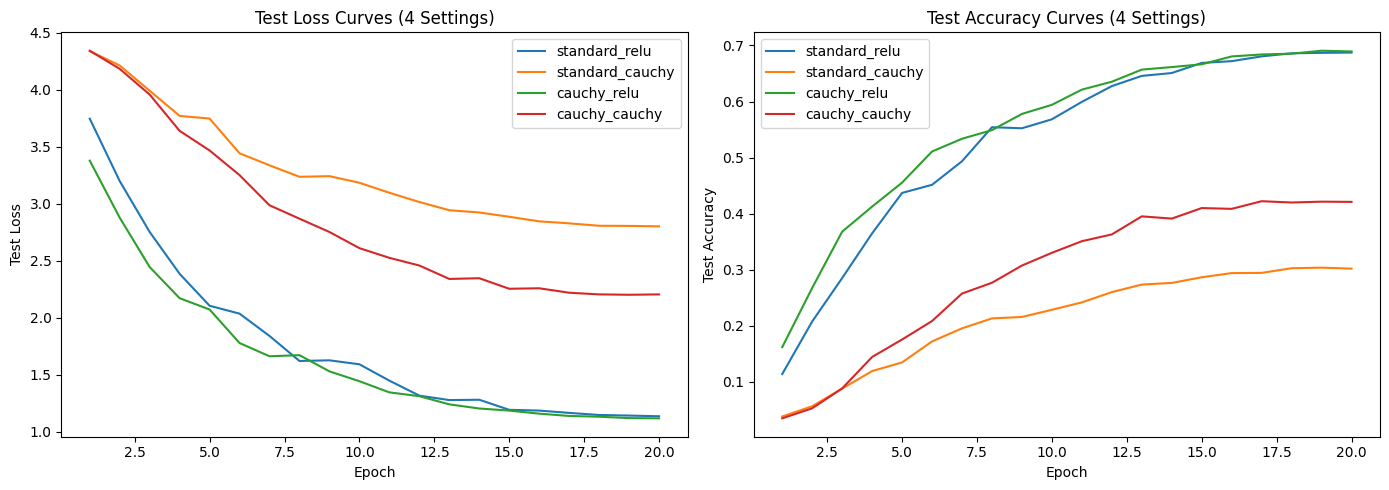

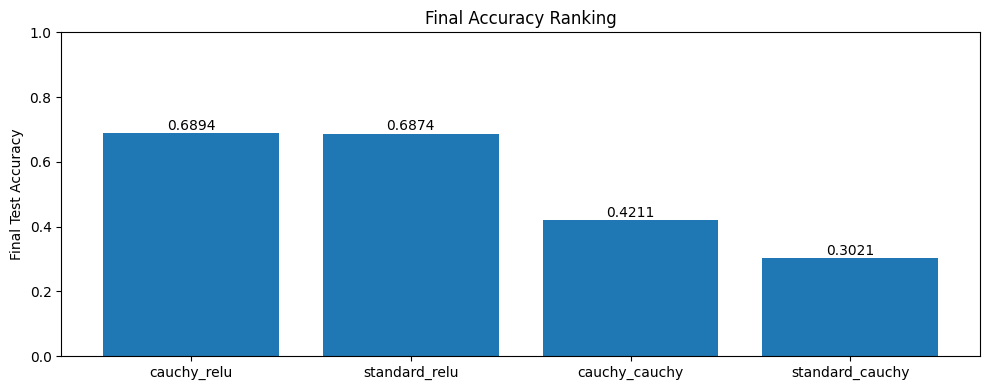

In [ ]:
# ===== 绘制训练曲线和精度排名 =====
epochs_axis = np.arange(1, cfg.epochs + 1)

# 创建2x1的子图：左为loss曲线，右为准确率曲线
plt.figure(figsize=(14, 5))

# 左图：测试Loss曲线
plt.subplot(1, 2, 1)
for exp_key, payload in results.items():
    plt.plot(epochs_axis, payload["history"]["test_loss"], label=exp_key)
plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss Curves (4 Settings)")
plt.legend()

# 右图：测试准确率曲线
plt.subplot(1, 2, 2)
for exp_key, payload in results.items():
    plt.plot(epochs_axis, payload["history"]["test_acc"], label=exp_key)
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.title("Test Accuracy Curves (4 Settings)")
plt.legend()
plt.tight_layout()

# ===== 按最终准确率排序并绘制柱状图 =====
# 对4个实验按最终精度排序
ranked = sorted(results.items(), key=lambda kv: kv[1]["final_test_acc"], reverse=True)
labels = [k for k, _ in ranked]
vals = [v["final_test_acc"] for _, v in ranked]

# 绘制准确率排名柱状图
plt.figure(figsize=(10, 4))
plt.bar(labels, vals)
plt.ylim(0, 1.0)
plt.ylabel("Final Test Accuracy")
plt.title("Final Accuracy Ranking")
# 在每个柱子上显示精确值
for i, v in enumerate(vals):
    plt.text(i, v + 0.01, f"{v:.4f}", ha="center")
plt.tight_layout()

In [ ]:
@torch.no_grad()
def collect_predictions(model, loader, device):
    """
    收集模型在整个dataset上的预测结果和真实标签。
    
    用途：
        用于计算混淆矩阵、逐类准确率等详细指标。
    
    参数：
        model (nn.Module)：预测模型
        loader (DataLoader)：数据加载器
        device (torch.device)：计算设备
        
    返回：
        tuple：(predictions, targets)
            predictions (Tensor)：模型预测的类别索引，形状(N,)
            targets (Tensor)：真实类别索引，形状(N,)
    """
    model.eval()
    all_preds = []
    all_targets = []
    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        logits = model(xb)
        preds = logits.argmax(dim=1).cpu()  # 获取预测类别
        all_preds.append(preds)
        all_targets.append(yb)
    return torch.cat(all_preds), torch.cat(all_targets)


# ===== 加载最好的模型并进行详细评估 =====
# 从best_key中解析残差模式和激活模式
best_residual, best_activation = best_key.split("_", 1)

# 创建新的模型实例并加载最好的权重
best_model = CauchyCNN(
    num_classes=len(classes),
    base_channels=cfg.base_channels,
    activation_mode=best_activation,
    residual_mode=best_residual,
).to(device)
best_model.load_state_dict(best_model_state)

# 在整个测试集上收集预测
preds, targets = collect_predictions(best_model, test_loader, device)

# 计算总体精度
overall_acc = (preds == targets).float().mean().item()
print(f"Best setting: {best_key}")
print(f"Final Test Accuracy (best model): {overall_acc:.4f}")

# ===== 逐类精度分析 =====
# 构建混淆矩阵
num_classes = len(classes)
cm = torch.zeros(num_classes, num_classes, dtype=torch.int64)
for t, p in zip(targets, preds):
    cm[int(t), int(p)] += 1

# 计算逐类准确率（对角线 / 行和）
per_class_acc = cm.diag().float() / cm.sum(dim=1).clamp(min=1).float()

# 打印每个类别的准确率
for i, name in enumerate(classes):
    print(f"{name:>10s}: {per_class_acc[i].item():.4f}")

Best setting: cauchy_relu
Final Test Accuracy (best model): 0.6894
     apple: 0.8200
aquarium_fish: 0.7800
      baby: 0.5900
      bear: 0.4700
    beaver: 0.6200
       bed: 0.6900
       bee: 0.7500
    beetle: 0.7000
   bicycle: 0.8600
    bottle: 0.8000
      bowl: 0.5000
       boy: 0.4600
    bridge: 0.7800
       bus: 0.6800
 butterfly: 0.5900
     camel: 0.7400
       can: 0.6900
    castle: 0.8200
caterpillar: 0.7000
    cattle: 0.6700
     chair: 0.8500
chimpanzee: 0.8300
     clock: 0.6700
     cloud: 0.8300
 cockroach: 0.8000
     couch: 0.5800
      crab: 0.5700
 crocodile: 0.5100
       cup: 0.7800
  dinosaur: 0.6700
   dolphin: 0.6400
  elephant: 0.6700
  flatfish: 0.6500
    forest: 0.5600
       fox: 0.7200
      girl: 0.4100
   hamster: 0.7700
     house: 0.7600
  kangaroo: 0.5400
  keyboard: 0.8600
      lamp: 0.5800
lawn_mower: 0.8700
   leopard: 0.7400
      lion: 0.7200
    lizard: 0.4300
   lobster: 0.6100
       man: 0.5000
maple_tree: 0.5400
motorcycle: 0.910

In [ ]:
# ===== 保存检查点 =====
# 保存完整的实验结果、最好的模型和配置，以便后续加载和分析
ckpt_path = "./cauchy_cnn_cifar100_ablation.pt"
torch.save(
    {
        "best_key": best_key,  # 最好配置的标识符（如"standard_relu"）
        "best_model_state_dict": best_model_state,  # 最好模型的权重
        "results": results,  # 所有4个实验的完整结果
        "config": cfg.__dict__,  # 训练配置参数
        "classes": classes,  # 类别名称列表
        "experiment_grid": experiment_grid,  # ablation实验配置
    },
    ckpt_path,
)
print(f"Saved checkpoint to {ckpt_path}")

Saved checkpoint to ./cauchy_cnn_cifar100_ablation.pt


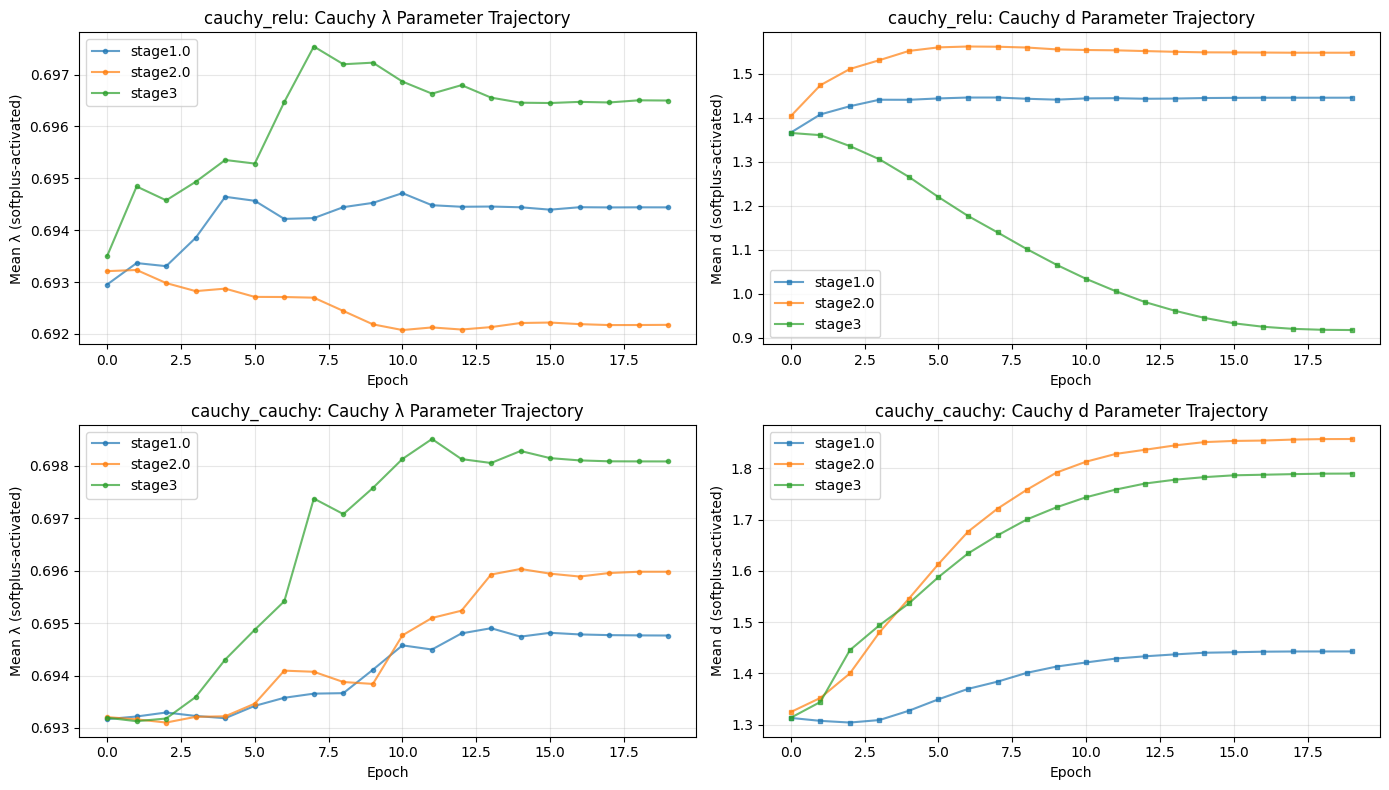

In [ ]:
# ===== 可视化Cauchy参数在训练过程中的轨迹 =====
# 仅显示residual_mode为"cauchy"的两个实验的参数演化

# 筛选出使用Cauchy残差模式的实验
cauchy_experiments = [k for k in results.keys() if results[k]["residual_mode"] == "cauchy"]

if cauchy_experiments:
    # 为每个Cauchy实验创建lambda和d参数对比图
    fig, axes = plt.subplots(len(cauchy_experiments), 2, figsize=(14, 4 * len(cauchy_experiments)))
    if len(cauchy_experiments) == 1:
        axes = axes.reshape(1, -1)

    for idx, exp_key in enumerate(cauchy_experiments):
        history = results[exp_key]["history"]
        params_list = history["cauchy_params"]

        ax_lambda = axes[idx, 0]
        ax_d = axes[idx, 1]

        # 获取所有RestageStage模块的名称
        stage_names = [name for name in params_list[0].keys() if params_list[0][name] is not None]

        # 为每个阶段绘制参数曲线
        for stage_name in stage_names:
            lambda_vals = []
            d_vals = []
            # 遍历每个epoch收集参数值
            for epoch_params in params_list:
                if epoch_params and stage_name in epoch_params:
                    # 计算该阶段所有参数的平均值
                    lambda_vals.append(epoch_params[stage_name]["lambda"].mean())
                    d_vals.append(epoch_params[stage_name]["d"].mean())

            epochs_range = np.arange(len(lambda_vals))
            # 绘制lambda和d的演化曲线
            ax_lambda.plot(epochs_range, lambda_vals, label=stage_name, marker="o", markersize=3, alpha=0.7)
            ax_d.plot(epochs_range, d_vals, label=stage_name, marker="s", markersize=3, alpha=0.7)

        ax_lambda.set_xlabel("Epoch")
        ax_lambda.set_ylabel("Mean λ (softplus-activated)")
        ax_lambda.set_title(f"{exp_key}: Cauchy λ Parameter Trajectory")
        ax_lambda.legend()
        ax_lambda.grid(alpha=0.3)

        ax_d.set_xlabel("Epoch")
        ax_d.set_ylabel("Mean d (softplus-activated)")
        ax_d.set_title(f"{exp_key}: Cauchy d Parameter Trajectory")
        ax_d.legend()
        ax_d.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("No Cauchy residual experiments found in results.")

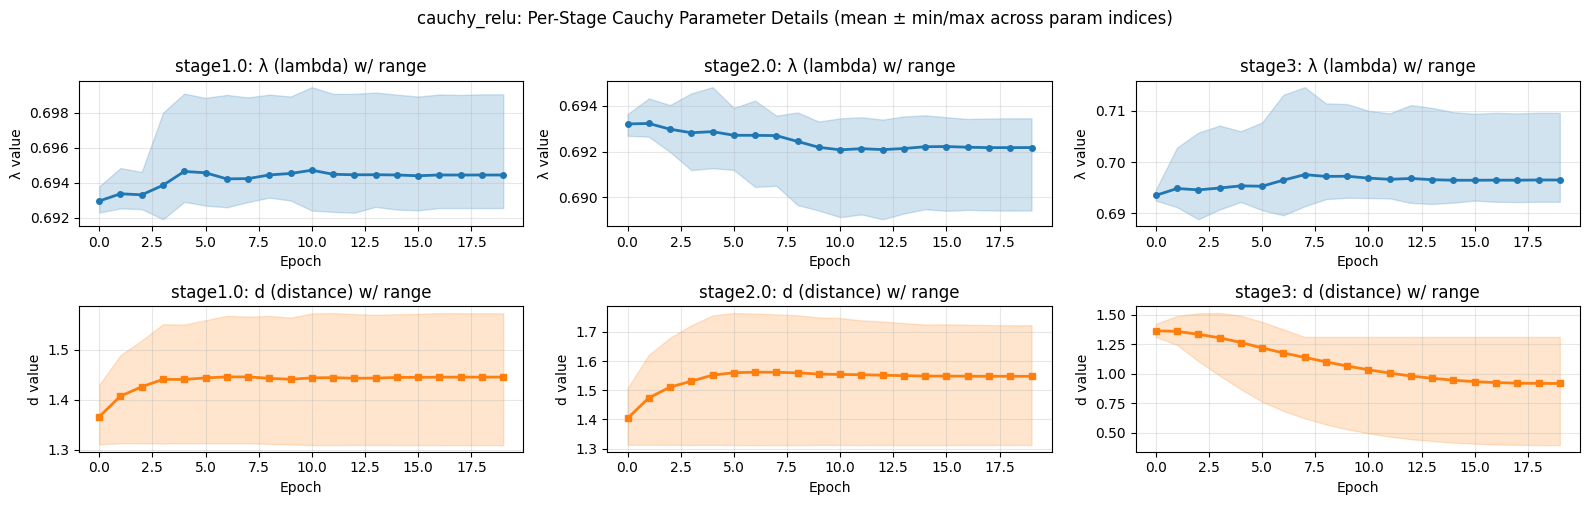

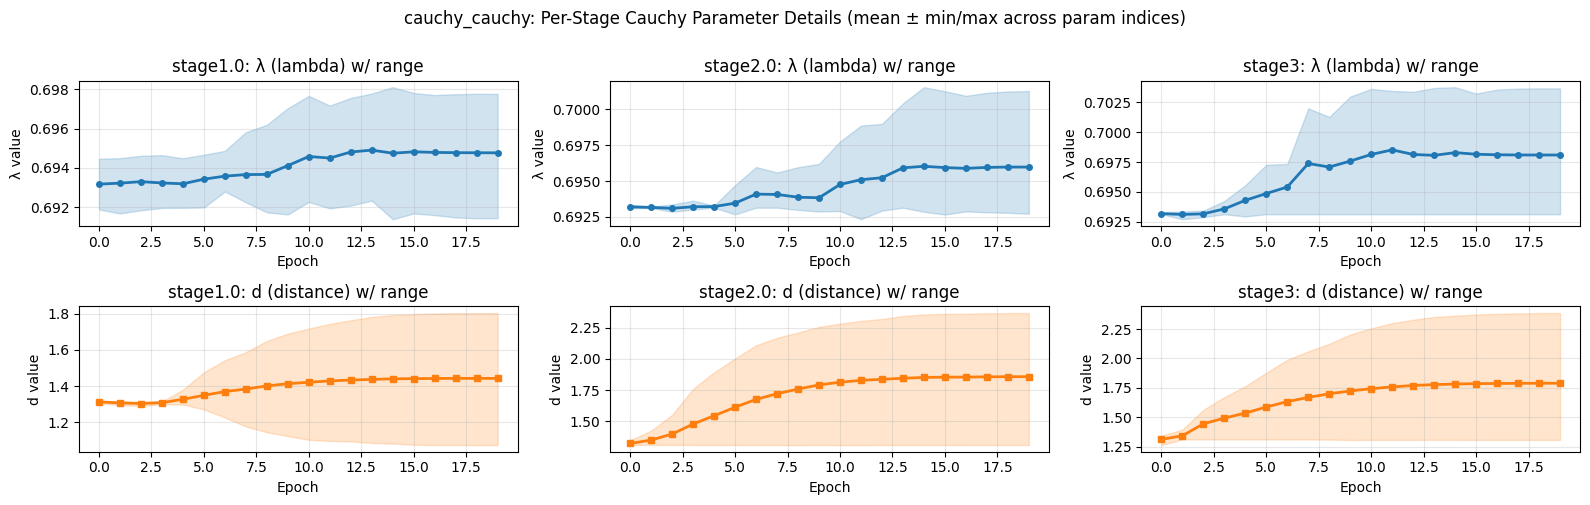

In [ ]:
# ===== 详细分析：Cauchy参数演化与测试准确率的关系 =====
# 为每个Cauchy实验绘制每个ResidualStage的lambda和d参数详情及其范围

for exp_key in cauchy_experiments:
    history = results[exp_key]["history"]
    params_list = history["cauchy_params"]
    test_acc = history["test_acc"]

    # 获取所有ResidualStage模块名
    stage_names = list(params_list[0].keys()) if params_list[0] else []

    if not stage_names:
        continue

    # 创建2行N列的图布局（N = ResidualStage数量）
    fig = plt.figure(figsize=(16, 5))
    num_stages = len(stage_names)

    # 上行：lambda参数细节
    for s_idx, stage_name in enumerate(stage_names):
        ax = plt.subplot(2, num_stages, s_idx + 1)

        lambda_vals = []
        d_vals = []
        # 从每个epoch的参数中收集当前stage的lambda和d
        for epoch_params in params_list:
            if epoch_params and stage_name in epoch_params:
                lambda_vals.append(epoch_params[stage_name]["lambda"])
                d_vals.append(epoch_params[stage_name]["d"])

        # 转为numpy数组便于计算统计量
        lambda_array = np.array(lambda_vals)
        d_array = np.array(d_vals)

        epochs_range = np.arange(len(lambda_vals))
        # 绘制lambda的平均值曲线及范围线
        ax.plot(epochs_range, lambda_array.mean(axis=1), "o-", linewidth=2, markersize=4, label="λ mean", color="C0")
        # 填充最小值到最大值的范围
        ax.fill_between(epochs_range, lambda_array.min(axis=1), lambda_array.max(axis=1), alpha=0.2, color="C0")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("λ value")
        ax.set_title(f"{stage_name}: λ (lambda) w/ range")
        ax.grid(alpha=0.3)

        # 下行：d参数细节
        ax_bottom = plt.subplot(2, num_stages, num_stages + s_idx + 1)
        ax_bottom.plot(epochs_range, d_array.mean(axis=1), "s-", linewidth=2, markersize=4, label="d mean", color="C1")
        ax_bottom.fill_between(epochs_range, d_array.min(axis=1), d_array.max(axis=1), alpha=0.2, color="C1")
        ax_bottom.set_xlabel("Epoch")
        ax_bottom.set_ylabel("d value")
        ax_bottom.set_title(f"{stage_name}: d (distance) w/ range")
        ax_bottom.grid(alpha=0.3)

    plt.suptitle(f"{exp_key}: Per-Stage Cauchy Parameter Details (mean ± min/max across param indices)", fontsize=12, y=1.00)
    plt.tight_layout()
    plt.show()

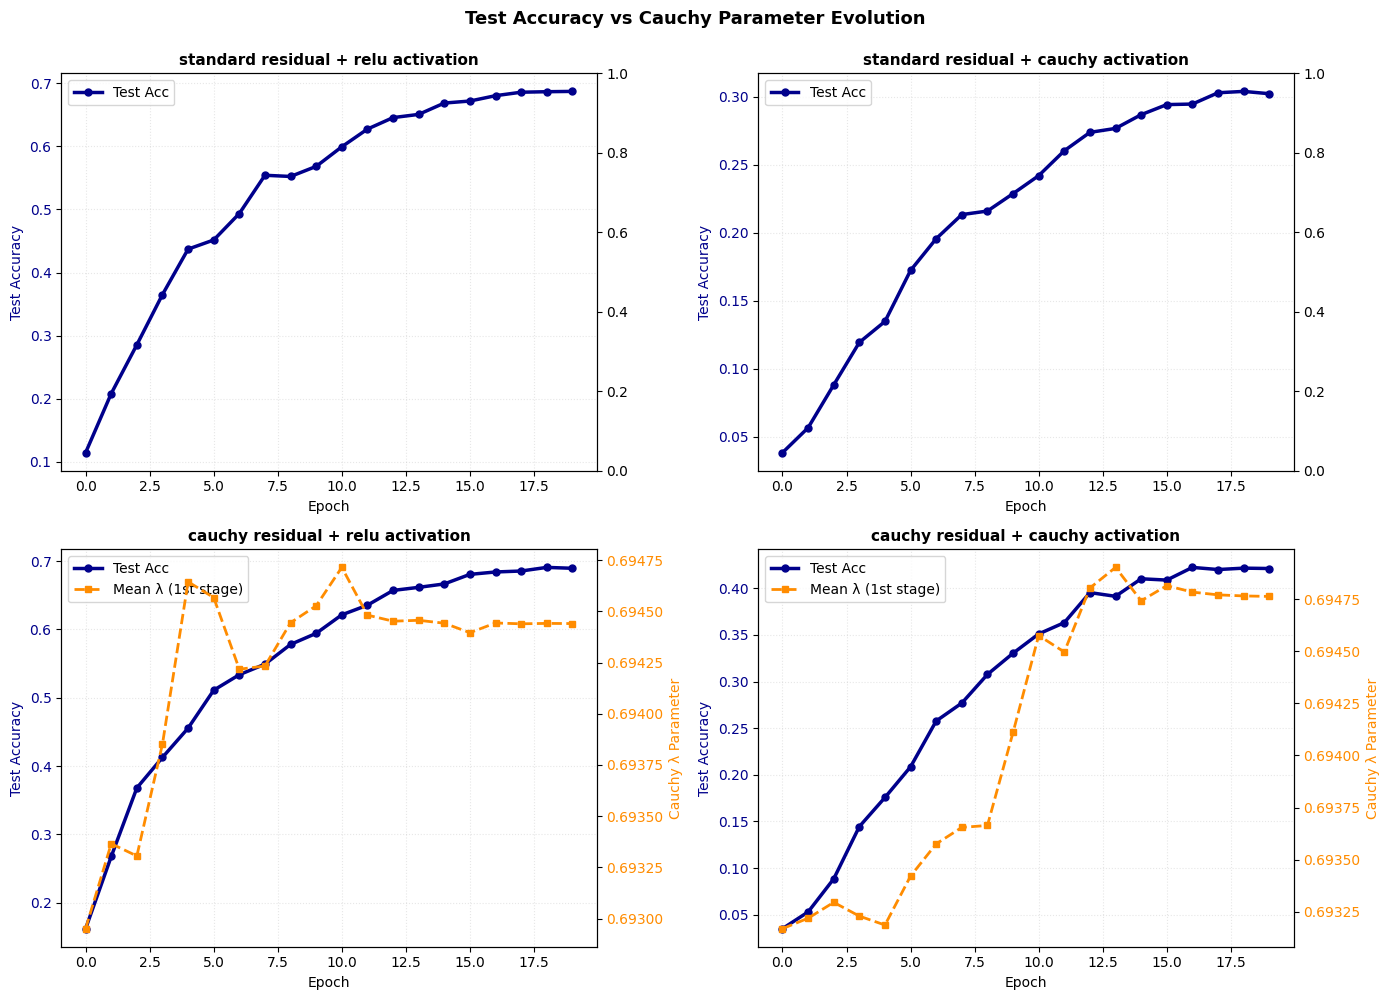

In [ ]:
# ===== 总结：Cauchy参数学习与测试准确率收敛的对比 =====
# 为4个实验绘制2x2图布局，每个子图显示测试准确率和Cauchy lambda参数的双轴对比

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, exp_key in enumerate(results.keys()):
    if idx >= 4:
        break
    row, col = idx // 2, idx % 2
    ax = axes[row, col]

    test_acc = results[exp_key]["history"]["test_acc"]
    residual_mode = results[exp_key]["residual_mode"]
    activation_mode = results[exp_key]["activation_mode"]

    # 创建双y轴：左轴为准确率，右轴为参数
    ax2 = ax.twinx()

    epochs_range = np.arange(len(test_acc))
    # 主轴（左）：绘制测试准确率曲线
    line1 = ax.plot(epochs_range, test_acc, "o-", linewidth=2.5, markersize=5, label="Test Acc", color="darkblue")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Test Accuracy", color="darkblue")
    ax.tick_params(axis="y", labelcolor="darkblue")

    # 副轴（右）：如果是Cauchy残差模式，绘制lambda参数曲线
    if residual_mode == "cauchy":
        params_list = results[exp_key]["history"]["cauchy_params"]
        if params_list and params_list[0]:
            stage_names = list(params_list[0].keys())
            if stage_names:
                # 使用第一个ResidualStage的lambda参数进行对比
                stage_name = stage_names[0]
                lambda_vals = [p[stage_name]["lambda"].mean() if p and stage_name in p else np.nan for p in params_list]
                line2 = ax2.plot(epochs_range, lambda_vals, "s--", linewidth=2, markersize=4, label="Mean λ (1st stage)", color="darkorange")
                ax2.set_ylabel("Cauchy λ Parameter", color="darkorange")
                ax2.tick_params(axis="y", labelcolor="darkorange")
                lines = line1 + line2
                labels = [l.get_label() for l in lines]
            else:
                lines = line1
                labels = [l.get_label() for l in lines]
        else:
            lines = line1
            labels = [l.get_label() for l in lines]
    else:
        lines = line1
        labels = [l.get_label() for l in lines]

    # 设置子图标题
    ax.set_title(f"{residual_mode} residual + {activation_mode} activation", fontsize=11, fontweight="bold")
    ax.grid(alpha=0.3, linestyle=":")
    ax.legend(lines, labels, loc="upper left")

plt.suptitle("Test Accuracy vs Cauchy Parameter Evolution", fontsize=13, fontweight="bold", y=0.995)
plt.tight_layout()
plt.show()